# Analisis y predicción de Ventas Parte 4.

In [ ]:
# Primero conectamos con Google Drive (Si esque estamos trabajando en Google Colab).
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Importamos librerias.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Continuar desde la Parte III.
Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.

In [2]:
# Importamos los datos exportados desde la parte III.
# Carga el archivo retail_sales.csv en un DataFrame de Pandas.
path = "../data/retail_sales_dataset_edit.csv"
df = pd.read_csv(path)
# Muestra las primeras 10 filas del DataFrame para confirmar que los datos se han cargado correctamente.
df.head(10)

,Unnamed: 0,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,TA Normalized,Q Normalized,Type of Sale,TA Desv
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,0.666667,Mid,-0.154937
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,0.333333,Mid,0.275443
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,0.000000,Low,-0.215696
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506,0.000000,Low,0.022278
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975,0.333333,Mid,-0.180253
5,5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,0.002532,0.000000,Low,-0.215696
6,6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,0.012658,0.333333,Mid,-0.205570
7,7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,0.037975,1.000000,High,-0.180253
8,8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,0.291139,0.333333,Mid,0.072911
9,9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,0.088608,1.000000,High,-0.129620


# Análisis Descriptivo y Visualización.
- Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.

In [6]:
# Utilizamos el .describe() sobre la columna Total Amount Normalized para observar el total de ventas normalizado.
df["TA Normalized"].describe().T

count    1000.000000
mean        0.218228
std         0.283543
min         0.000000
25%         0.017722
50%         0.055696
75%         0.443038
max         1.000000
Name: TA Normalized, dtype: float64

Podemos observar en base al promedio y la desviación estandar, que la mayoria de las ventas se concentran en montos pequeños en comparación al resto de la población.

Pero además el percentil 75 indica que muchas de las compras también son ventas de un valor promedio, y pocas ventas corresponden a valores mas altos. Indicando asi que hay una gran dispersión de los datos.

- Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.

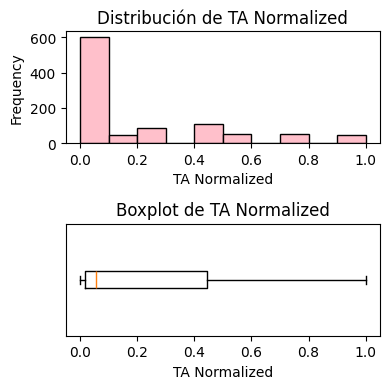

In [7]:
# Creamos un histograma y un boxplot para visualizar TA Normalized.
# Declaramos la figura con 2 filas y 1 columna.
fig, axes = plt.subplots(2, 1, figsize=(4, 4))

# Histograma.
axes[0].hist(df["TA Normalized"], bins=10, color="pink", edgecolor='black')
axes[0].set_title("Distribución de TA Normalized")
axes[0].set_xlabel("TA Normalized")
axes[0].set_ylabel("Frequency")

# Boxplot.
axes[1].boxplot(df["TA Normalized"], vert=False)
axes[1].set_title("Boxplot de TA Normalized")
axes[1].set_xlabel("TA Normalized")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

Confirmamos la primera parte de nuestro analisis, que las ventas se concentran en compras pequeñas a comparación del total, y también que los datos están muy dispersos.

- Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.

In [14]:
# Nos aseguramos de que la columna Date esté guardada correctamente como timestamp.
df["Date"] = pd.to_datetime(df["Date"])

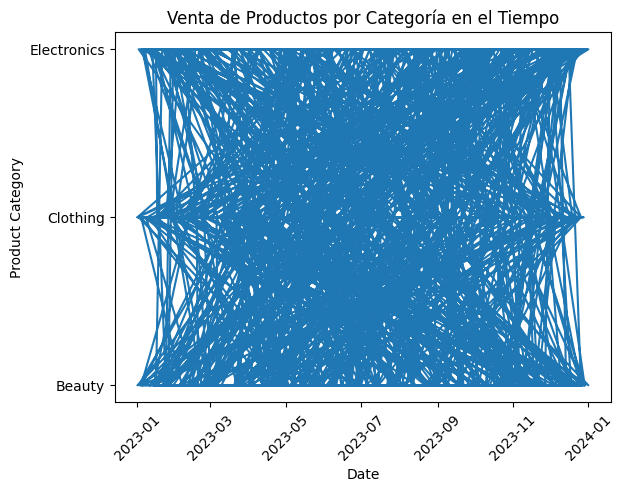

In [19]:
# Crear gráfico.
plt.plot(df["Date"], df["Product Category"])

# Añadir título y etiquetas.
plt.title("Venta de Productos por Categoría en el Tiempo")
plt.xlabel("Date")
plt.ylabel("Product Category")
plt.xticks(rotation=45)

# Mostrar.
plt.show()

No es el gráfico más bello de todos, pero nos sirve para observar que cada categoría se mantuvo presente en el tiempo. Ninguna tuvo un periodo de inactividad o algo relevante.

- Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.

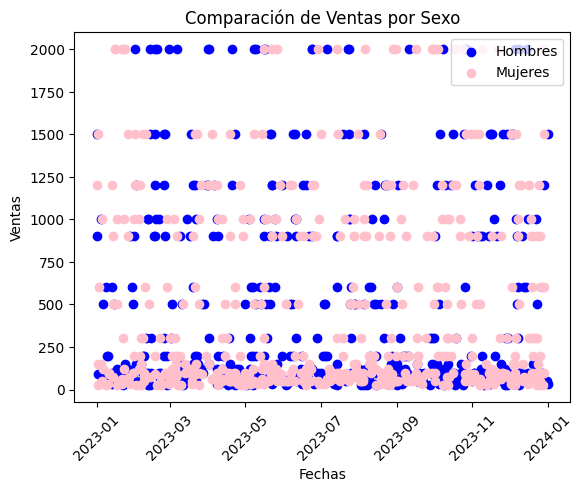

In [25]:
# Vamos a comparar la cantidad de ventas por Sexo.
# Creamos dos grupos de datos.
df_male = df[df["Gender"] == "Male"]
df_female = df[df["Gender"] == "Female"]

# Obtenemos la información relevante.
male_dates = df_male["Date"]
male_sales = df_male["Total Amount"]

female_dates = df_female["Date"]
female_sales = df_female["Total Amount"]

# Creamos un scatter plot.
plt.scatter(male_dates, male_sales, color="blue", label="Hombres")
plt.scatter(female_dates, female_sales, color="pink", label="Mujeres")

# Añadir título y etiquetas.
plt.title("Comparación de Ventas por Sexo")
plt.xlabel("Fechas")
plt.ylabel("Ventas")
plt.xticks(rotation=45)

# Añadir leyenda.
plt.legend()

# Mostramos el gráfico.
plt.show()

Con un gráfico simple de ventas en el tiempo, dividida entre hombres y mujeres. Podemos observar que tanto hombres como mujeres realizaron una cantidad de compras prácticamente identicas, no parece haber una diferencia significiativa entre uno y otro.
- Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

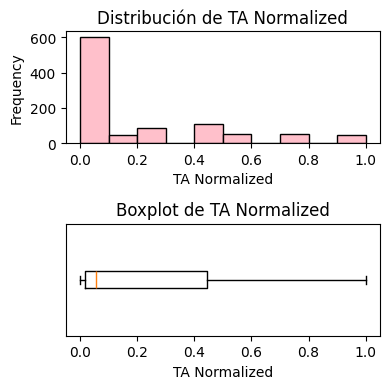

In [27]:
# Para esta última parte podemos reutilizar nuestro primer gráfico que cumple lo que se pide:
# Creamos un histograma y un boxplot para visualizar TA Normalized.
# Declaramos la figura con 2 filas y 1 columna.
fig, axes = plt.subplots(2, 1, figsize=(4, 4))

# Histograma.
axes[0].hist(df["TA Normalized"], bins=10, color="pink", edgecolor='black')
axes[0].set_title("Distribución de TA Normalized")
axes[0].set_xlabel("TA Normalized")
axes[0].set_ylabel("Frequency")

# Boxplot.
axes[1].boxplot(df["TA Normalized"], vert=False)
axes[1].set_title("Boxplot de TA Normalized")
axes[1].set_xlabel("TA Normalized")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

Aqui podemos observar que los valores atipicos están desde 0.5 en adelante, es decir las ventas que van desde la venta media, hasta la venta más alta realizada.
Habiendo una concentración en valores de venta en la mitad inferior, y siendo los valores anormales, las ventas de mayor monto.

Como conclusión final, podemos ver que las ventas se concentran siempre en montos bajos, tal y como se espera de una población común. Y en este caso específico, hombres y mujeres realizaron una cantidad igualitaria de compras a lo largo de los datos.